In [ ]:
import subprocess, sys, os
 
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch==2.2.0+cu118", "torchvision==0.17.0+cu118",
    "--index-url", "https://download.pytorch.org/whl/cu118", "-q"
])
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "numpy==1.26.4", "--force-reinstall", "-q"
])
subprocess.check_call([
    sys.executable, "-m", "pip", "uninstall", "ray", "-y"
])
 
os.execv(sys.executable, [sys.executable] + sys.argv)

PyTorch: 2.2.0+cu118
CUDA available: True
Device: Tesla P100-PCIE-16GB
实际类别数: 35
训练集: 8320 张
验证集: 1040 张
模型参数量: 41,473,411

开始训练 Faster R-CNN，共 20 epochs...
  Epoch 1 [100/2080] loss: 0.2708
  Epoch 1 [200/2080] loss: 0.4075
  Epoch 1 [300/2080] loss: 0.2075
  Epoch 1 [400/2080] loss: 0.3631
  Epoch 1 [500/2080] loss: 0.1809
  Epoch 1 [600/2080] loss: 0.4066
  Epoch 1 [700/2080] loss: 0.2914
  Epoch 1 [800/2080] loss: 0.3149
  Epoch 1 [900/2080] loss: 0.2083
  Epoch 1 [1000/2080] loss: 0.1738
  Epoch 1 [1100/2080] loss: 0.1534
  Epoch 1 [1200/2080] loss: 0.1689
  Epoch 1 [1300/2080] loss: 0.3039
  Epoch 1 [1400/2080] loss: 0.3528
  Epoch 1 [1500/2080] loss: 0.1809
  Epoch 1 [1600/2080] loss: 0.3736
  Epoch 1 [1700/2080] loss: 0.1885
  Epoch 1 [1800/2080] loss: 0.2182
  Epoch 1 [1900/2080] loss: 0.1842
  Epoch 1 [2000/2080] loss: 0.3812
Epoch 1/20 | Train Loss: 0.2729 | Val Loss: 0.2908 | Time: 18.2min | ETA: 346.1min
  ✅ 保存最佳模型 (val_loss: 0.2908)
  Epoch 2 [100/2080] loss: 0.1075
  Epo

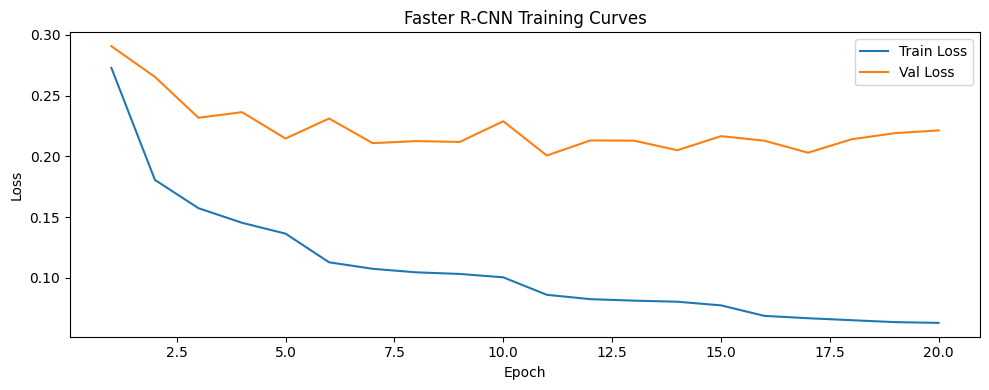

训练曲线已保存

=== Faster R-CNN 训练结果 ===
  model: Faster R-CNN ResNet50-FPN
  epochs: 20
  best_val_loss: 0.2007
  train_time_min: 366.5
  final_train_loss: 0.0629
  final_val_loss: 0.2214

✅ 模型已保存: /kaggle/working/faster_rcnn/best.pt (158.7 MB)
请在右侧 Output 面板中下载 best.pt


In [1]:
# ── Cell 2: 训练代码（Cell 1 重启后运行这个）────────────────
# ============================================================
 
import os, time, json, glob
import numpy as np
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
 
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0)}")
 
# ── 配置 ──────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/youssefahmed003/junk-food-object-detection-dataset-yolo-format/yolo_dataset"
SAVE_DIR = "/kaggle/working/faster_rcnn"
os.makedirs(SAVE_DIR, exist_ok=True)
 
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
NUM_EPOCHS = 20
BATCH_SIZE = 4
LEARNING_RATE = 0.005
NUM_WORKERS = 2
 
# 自动从数据集读取实际类别数
import glob as _glob
_label_files = _glob.glob(f"{DATASET_PATH}/labels/train/*.txt")
_class_ids = set()
for _f in _label_files[:500]:
    with open(_f) as _fp:
        for _line in _fp:
            _parts = _line.strip().split()
            if _parts:
                _class_ids.add(int(_parts[0]))
NUM_CLASSES = max(_class_ids) + 1 + 1  # +1 for background
NAMES = [str(i) for i in range(NUM_CLASSES - 1)]
print(f"实际类别数: {NUM_CLASSES - 1}")
 
# ── Dataset 类（YOLO格式转Faster R-CNN格式）──────────────────
class JunkFoodDataset(Dataset):
    def __init__(self, img_dir, label_dir, names, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.names = names
        self.transforms = transforms
        self.imgs = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
 
    def __len__(self):
        return len(self.imgs)
 
    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(
            self.label_dir,
            os.path.splitext(img_name)[0] + ".txt"
        )
 
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
 
        boxes = []
        labels = []
 
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls, cx, cy, bw, bh = map(float, parts)
                    # YOLO格式转换为 [x1, y1, x2, y2]
                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h
                    x2 = (cx + bw / 2) * w
                    y2 = (cy + bh / 2) * h
                    # 过滤无效框
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(int(cls) + 1)  # +1 因为0是背景
 
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
 
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }
 
        img = torchvision.transforms.functional.to_tensor(img)
 
        return img, target
 
 
def collate_fn(batch):
    return tuple(zip(*batch))
 
 
# ── 加载数据集 ────────────────────────────────────────────────
train_dataset = JunkFoodDataset(
    img_dir=f"{DATASET_PATH}/images/train",
    label_dir=f"{DATASET_PATH}/labels/train",
    names=NAMES
)
val_dataset = JunkFoodDataset(
    img_dir=f"{DATASET_PATH}/images/val",
    label_dir=f"{DATASET_PATH}/labels/val",
    names=NAMES
)
 
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn
)
 
print(f"训练集: {len(train_dataset)} 张")
print(f"验证集: {len(val_dataset)} 张")
 
# ── 构建模型 ──────────────────────────────────────────────────
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)
print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
 
# ── 优化器 ────────────────────────────────────────────────────
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params, lr=LEARNING_RATE,
    momentum=0.9, weight_decay=0.0005
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5
)
 
# ── 训练函数 ──────────────────────────────────────────────────
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()
    total_loss = 0
    for i, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
 
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
 
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
 
        total_loss += losses.item()
 
        if (i + 1) % 100 == 0:
            print(f"  Epoch {epoch} [{i+1}/{len(loader)}] loss: {losses.item():.4f}")
 
    return total_loss / len(loader)
 
 
# ── 简单验证（计算验证集loss）────────────────────────────────
def evaluate(model, loader, device):
    model.train()  # Faster R-CNN 需要 train 模式才能计算 loss
    total_loss = 0
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
    return total_loss / len(loader)
 
 
# ── 训练循环 ──────────────────────────────────────────────────
print(f"\n开始训练 Faster R-CNN，共 {NUM_EPOCHS} epochs...")
train_losses = []
val_losses = []
best_val_loss = float('inf')
start = time.time()
 
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
 
    train_loss = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch)
    val_loss = evaluate(model, val_loader, DEVICE)
    lr_scheduler.step()
 
    train_losses.append(train_loss)
    val_losses.append(val_loss)
 
    epoch_time = time.time() - epoch_start
    elapsed = time.time() - start
    eta = elapsed / epoch * (NUM_EPOCHS - epoch)
 
    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Time: {epoch_time/60:.1f}min | "
          f"ETA: {eta/60:.1f}min")
 
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"{SAVE_DIR}/best.pt")
        print(f"  ✅ 保存最佳模型 (val_loss: {val_loss:.4f})")
 
    # 每5个epoch保存一次中间结果
    if epoch % 5 == 0:
        with open(f"{SAVE_DIR}/losses.json", "w") as f:
            json.dump({"train": train_losses, "val": val_losses}, f)
 
total_time = time.time() - start
print(f"\n✅ 训练完成！总用时: {total_time/60:.1f} 分钟")
print(f"最佳验证Loss: {best_val_loss:.4f}")
 
# ── 保存训练曲线 ──────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150)
plt.show()
print("训练曲线已保存")
 
# ── 保存结果 ──────────────────────────────────────────────────
result = {
    "model": "Faster R-CNN ResNet50-FPN",
    "epochs": NUM_EPOCHS,
    "best_val_loss": round(best_val_loss, 4),
    "train_time_min": round(total_time / 60, 1),
    "final_train_loss": round(train_losses[-1], 4),
    "final_val_loss": round(val_losses[-1], 4),
}
with open(f"{SAVE_DIR}/result.json", "w") as f:
    json.dump(result, f, indent=2)
 
print(f"\n=== Faster R-CNN 训练结果 ===")
for k, v in result.items():
    print(f"  {k}: {v}")
 
# ── 确认文件 ──────────────────────────────────────────────────
weight_path = f"{SAVE_DIR}/best.pt"
if os.path.exists(weight_path):
    size_mb = os.path.getsize(weight_path) / (1024*1024)
    print(f"\n✅ 模型已保存: {weight_path} ({size_mb:.1f} MB)")
    print("请在右侧 Output 面板中下载 best.pt")
else:
    print("❌ 找不到权重文件")